# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [12]:
from __future__ import annotations

import torch
from torch import nn

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [13]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.wieght = nn.Parameter(torch.empty(out_features, in_features))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_features))
        else:
            self.bias = None
        if self.bias is not None:
            with torch.no_grad():
                self.bias.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        y = x @ self.wieght.T
        if self.bias is not None:
            y = y + self.bias
        return y

In [14]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        self.num_embeddings = num_embeddings
        self.embedding_dim = embedding_dim
        self.weight = nn.Parameter(torch.empty(num_embeddings, embedding_dim))

        with torch.no_grad():
            self.weight.normal_(0, 1)  # Initialize weights with standard normal distribution

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        return self.weight[idx]

In [15]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()
        if not (0 <= p < 1):
            raise ValueError("Dropout probability must be in the range [0, 1).")
        self.p = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        if not self.training:
            return x

        if self.p == 0:
            return x

        mask = torch.rand_like(x) >= self.p
        return mask * x / (1 - self.p)

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [16]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.elementwise_affine = elementwise_affine
        if self.elementwise_affine:
            self.weight = nn.Parameter(torch.ones(normalized_shape))
            self.bias = nn.Parameter(torch.zeros(normalized_shape))
        else:
            self.register_parameter("weight", None)
            self.register_parameter("bias", None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        mean = x.mean(dim=-1, keepdim=True)
        var = ((x - mean) ** 2).mean(dim=-1, keepdim=True)
        x_normalized = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            x_normalized = self.weight * x_normalized + self.bias
        return x_normalized

In [17]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        self.normalized_shape = normalized_shape
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(normalized_shape))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        rms = torch.sqrt(torch.mean(x ** 2, dim = -1, keepdim=True) + self.eps)
        x_normalized = x / rms
        return self.weight * x_normalized

## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [18]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        if depth < 1:
            raise ValueError("Depth must be at least 1.")

        layers = []
        if depth == 1:
            layers.append(Linear(in_dim, out_dim))
        else:
            layers.append(Linear(in_dim, hidden_dim))
            if use_layernorm:
                layers.append(LayerNorm(hidden_dim))
            layers.append(nn.GELU())
            for _ in range(depth - 2):
                layers.append(Linear(hidden_dim, hidden_dim))
                if use_layernorm:
                    layers.append(LayerNorm(hidden_dim))
                layers.append(nn.GELU())
            layers.append(Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [19]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model

        self.linear1 = Linear(d_model, d_ff)
        self.activation = nn.GELU()
        self.linear2 = Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear2(self.activation(self.linear1(x)))

In [20]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        return x + self.fn(x, *args, **kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [21]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [22]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# TODO: define the dataloaders

In [23]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    log_probs = torch.nn.functional.log_softmax(logits, dim = -1)
    return -log_probs.gather(dim=-1, index=targets.unsqueeze(-1)).mean()

In [24]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        self.proj = Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        return self.proj(x)

In [25]:
def accuracy(loader):
    """
    Compute accuracy over a dataloader
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            preds = torch.argmax(logits, dim=-1)
            correct += (preds == y).sum().item()
            total += y.numel()

    return correct / total

In [26]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    torch.manual_seed(seed)
    optimizer = torch.optim.Adamax(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        model.train()
        for x, y in train_data_loader:
            optimizer.zero_grad()
            logits = model(x)
            loss = cross_entropy_from_logits(logits, y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        # Evaluate on test set
        test_acc = accuracy(test_data_loader)
        print(f"Epoch {epoch + 1}/{epochs}, Test Accuracy: {test_acc:.4f}")

    return losses


Epoch 1/3, Test Accuracy: 0.8920
Epoch 2/3, Test Accuracy: 0.8970
Epoch 3/3, Test Accuracy: 0.9200
Final quick-test accuracy: 92.00%


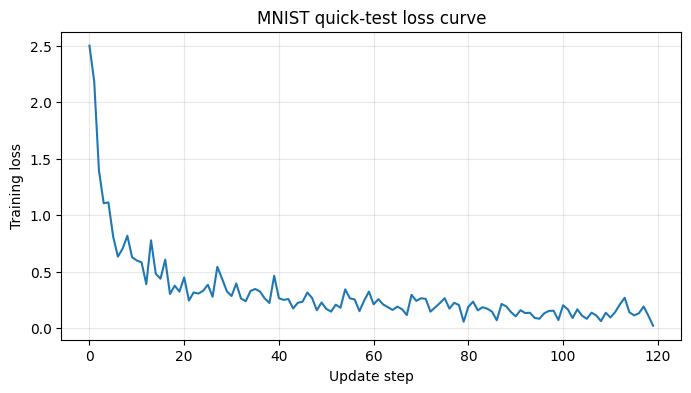

In [27]:
# Quick end-to-end test for the classification section.
# Use small MNIST subsets so this cell finishes much faster than full training.
from torch.utils.data import Subset
import matplotlib.pyplot as plt

torch.manual_seed(42)

quick_train_ds = Subset(train_ds, range(5_000))
quick_test_ds = Subset(test_ds, range(1_000))
train_loader = DataLoader(quick_train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(quick_test_ds, batch_size=256, shuffle=False)

# MNIST image: (1, 28, 28) -> flatten to 784 features -> MLP -> 10 logits.
model = nn.Sequential(
    nn.Flatten(),
    MLP(in_dim=28 * 28, hidden_dim=128, out_dim=64, depth=2),
    ClassificationHead(d_in=64, num_classes=10),
)

# Initialize the custom Linear parameters before training.
with torch.no_grad():
    for parameter in model.parameters():
        if parameter.ndim >= 2:
            nn.init.xavier_uniform_(parameter)
        else:
            parameter.zero_()

# Sanity-check the head and custom cross-entropy before training.
sample_images, sample_targets = next(iter(train_loader))
sample_logits = model(sample_images)
assert sample_logits.shape == (sample_images.shape[0], 10)
custom_loss = cross_entropy_from_logits(sample_logits, sample_targets)
reference_loss = torch.nn.functional.cross_entropy(sample_logits, sample_targets)
assert torch.allclose(custom_loss, reference_loss, atol=1e-6)

# This calls train_classifier(), which in turn calls accuracy() after every epoch.
losses = train_classifier(
    model=model,
    train_data_loader=train_loader,
    test_data_loader=test_loader,
    lr=1e-2,
    epochs=3,
    seed=42,
)

assert isinstance(losses, list) and len(losses) == 3 * len(train_loader)
assert all(torch.isfinite(torch.tensor(loss)) for loss in losses)
final_accuracy = accuracy(test_loader)
print(f"Final quick-test accuracy: {final_accuracy:.2%}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Update step")
plt.ylabel("Training loss")
plt.title("MNIST quick-test loss curve")
plt.grid(alpha=0.3)
plt.show()
